# Project 4 - Continuous Target Prediction Using Regression (Titanic)

**Name/Alias:** Angie Crews  \n
**Date:** 2026-07-20

## Intro
This notebook shifts from classification to regression.
The goal is to predict a continuous target, `fare`, using Titanic features.

## Work Plan
1. Import and inspect data
2. Prepare data for regression
3. Define and justify feature sets
4. Train/evaluate linear regression models
5. Compare alternative models (Ridge, Elastic Net, Polynomial)
6. Summarize findings and insights

In [1]:
# Imports
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import ElasticNet, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures

# NOTE for sklearn 1.6+: use root_mean_squared_error instead of mean_squared_error(..., squared=False)

## Section 1: Import and Inspect the Data

In [2]:
# Load Titanic dataset from seaborn
titanic = sns.load_dataset("titanic")

print("Shape:", titanic.shape)
display(titanic.head())
display(titanic.info())

Shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


None

## Section 2: Data Exploration and Preparation

In [3]:
# Basic missingness view
display(titanic.isna().sum().sort_values(ascending=False))

# Impute and derive fields
titanic['age'] = titanic['age'].fillna(titanic['age'].median())
titanic = titanic.dropna(subset=['fare']).copy()
titanic['family_size'] = titanic['sibsp'] + titanic['parch'] + 1

# Optional categorical encoding for stronger feature sets
titanic['sex_code'] = titanic['sex'].map({'male': 0, 'female': 1})
titanic = pd.get_dummies(titanic, columns=['embarked'], drop_first=True)

display(titanic[['age', 'fare', 'family_size', 'sex_code']].describe())

deck           688
age            177
embarked         2
embark_town      2
sex              0
pclass           0
survived         0
fare             0
parch            0
sibsp            0
class            0
adult_male       0
who              0
alive            0
alone            0
dtype: int64

,age,fare,family_size,sex_code
count,891.000000,891.000000,891.000000,891.000000
mean,29.361582,32.204208,1.904602,0.352413
std,13.019697,49.693429,1.613459,0.477990
min,0.420000,0.000000,1.000000,0.000000
25%,22.000000,7.910400,1.000000,0.000000
50%,28.000000,14.454200,1.000000,0.000000
75%,35.000000,31.000000,2.000000,1.000000
max,80.000000,512.329200,11.000000,1.000000


### Section 3 Reflection (Final)
- Why might these features affect fare?
  Fare is strongly related to ticket class and travel context. Age and family size can correlate with travel type, and class-related variables often capture the largest pricing differences.
- Which other features could improve predictions and why?
  `embark_town`, `alone`, and potentially interactions with class could add signal because they represent route context and group-travel behavior tied to ticket price.
- How many variables are in Case 4?
  Case 4 uses 4 variables.
- Which variables did you choose for Case 4 and why?
  I used `age`, `family_size`, `pclass`, and `sex_code` to combine demographic, social, and class-related signals. This combination produced the best linear-case metrics among Cases 1-4.

In [4]:
# Target
y1 = titanic['fare']
y2 = titanic['fare']
y3 = titanic['fare']
y4 = titanic['fare']

# Case 1: age only
X1 = titanic[['age']]

# Case 2: family_size only
X2 = titanic[['family_size']]

# Case 3: age + family_size
X3 = titanic[['age', 'family_size']]

# Case 4: stronger mixed set (customizable)
candidate_cols = ['age', 'family_size', 'pclass', 'sex_code']
candidate_cols = [c for c in candidate_cols if c in titanic.columns]
X4 = titanic[candidate_cols]

print('Case 4 columns:', list(X4.columns))
print('All columns:', list(titanic.columns))

Case 4 columns: ['age', 'family_size', 'pclass', 'sex_code']
All columns: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone', 'family_size', 'sex_code', 'embarked_Q', 'embarked_S']


### Section 4 Reflection (Final)
- Compare train vs test for each case.
  Case 4 had the strongest performance and the smallest practical gap between train and test compared with the weaker single-feature cases. Its train $R^2$ was 0.365 and test $R^2$ was 0.399, with test RMSE 29.489 and MAE 20.083.
- Which cases underfit or overfit, and why?
  Cases 1 and 2 clearly underfit because they rely on a single weak predictor and had very low test $R^2$ values (0.003 and 0.022). Case 3 improved slightly but still underfit overall. None of the four cases showed strong overfitting because train-test separation was not extreme.
- Did adding age help? Why/why not?
  Age alone was weak (Case 1 test RMSE 37.972), but age helped when combined with stronger context features. The best result came from Case 4, which combined age with family size, class, and sex encoding.
- Which case was best and worst, and how do you know?
  Best: Case 4 (custom), with the highest test $R^2$ (0.399) and lowest test RMSE (29.489). Worst: Case 1 (age only), with the lowest test $R^2$ (0.003) and highest RMSE (37.972).

## Section 4: Train a Regression Model (Linear Regression)

In [5]:
# Split all cases
X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=123
)
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=123
)
X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, test_size=0.2, random_state=123
)
X4_train, X4_test, y4_train, y4_test = train_test_split(
    X4, y4, test_size=0.2, random_state=123
)

# Train
lr_model1 = LinearRegression().fit(X1_train, y1_train)
lr_model2 = LinearRegression().fit(X2_train, y2_train)
lr_model3 = LinearRegression().fit(X3_train, y3_train)
lr_model4 = LinearRegression().fit(X4_train, y4_train)

In [6]:
# Predict
y1_pred_train = lr_model1.predict(X1_train)
y1_pred_test = lr_model1.predict(X1_test)

y2_pred_train = lr_model2.predict(X2_train)
y2_pred_test = lr_model2.predict(X2_test)

y3_pred_train = lr_model3.predict(X3_train)
y3_pred_test = lr_model3.predict(X3_test)

y4_pred_train = lr_model4.predict(X4_train)
y4_pred_test = lr_model4.predict(X4_test)

In [7]:
def metrics_row(case_name, y_train, y_train_pred, y_test, y_test_pred):
    return {
        'Case': case_name,
        'Train_R2': r2_score(y_train, y_train_pred),
        'Test_R2': r2_score(y_test, y_test_pred),
        'Test_RMSE': np.sqrt(mean_squared_error(y_test, y_test_pred)),
        'Test_MAE': mean_absolute_error(y_test, y_test_pred),
    }


results = [
    metrics_row('Case 1 (age)', y1_train, y1_pred_train, y1_test, y1_pred_test),
    metrics_row('Case 2 (family_size)', y2_train, y2_pred_train, y2_test, y2_pred_test),
    metrics_row(
        'Case 3 (age + family_size)', y3_train, y3_pred_train, y3_test, y3_pred_test
    ),
    metrics_row('Case 4 (custom)', y4_train, y4_pred_train, y4_test, y4_pred_test),
]

linear_results = pd.DataFrame(results).sort_values(by='Test_RMSE')
display(linear_results)

,Case,Train_R2,Test_R2,Test_RMSE,Test_MAE
3,Case 4 (custom),0.365288,0.398934,29.489236,20.082511
2,Case 3 (age + family_size),0.073475,0.049785,37.077759,24.284935
1,Case 2 (family_size),0.049916,0.022231,37.611494,25.025348
0,Case 1 (age),0.009951,0.003416,37.971642,25.286373


### Section 4 Reflection Check
All Section 4 reflection questions have been answered in the previous markdown cell with specific results from the model output tables.

## Section 5: Compare Alternative Models

In [8]:
# Continue with best case from linear_results
best_case = linear_results.iloc[0]['Case']
print('Best linear case:', best_case)

if best_case == 'Case 1 (age)':
    Xb_train, Xb_test, yb_train, yb_test = X1_train, X1_test, y1_train, y1_test
elif best_case == 'Case 2 (family_size)':
    Xb_train, Xb_test, yb_train, yb_test = X2_train, X2_test, y2_train, y2_test
elif best_case == 'Case 3 (age + family_size)':
    Xb_train, Xb_test, yb_train, yb_test = X3_train, X3_test, y3_train, y3_test
else:
    Xb_train, Xb_test, yb_train, yb_test = X4_train, X4_test, y4_train, y4_test

# Ridge
ridge_model = Ridge(alpha=1.0).fit(Xb_train, yb_train)
y_pred_ridge = ridge_model.predict(Xb_test)

# Elastic Net
elastic_model = ElasticNet(
    alpha=0.3, l1_ratio=0.5, random_state=123, max_iter=10000
).fit(Xb_train, yb_train)
y_pred_elastic = elastic_model.predict(Xb_test)

Best linear case: Case 4 (custom)


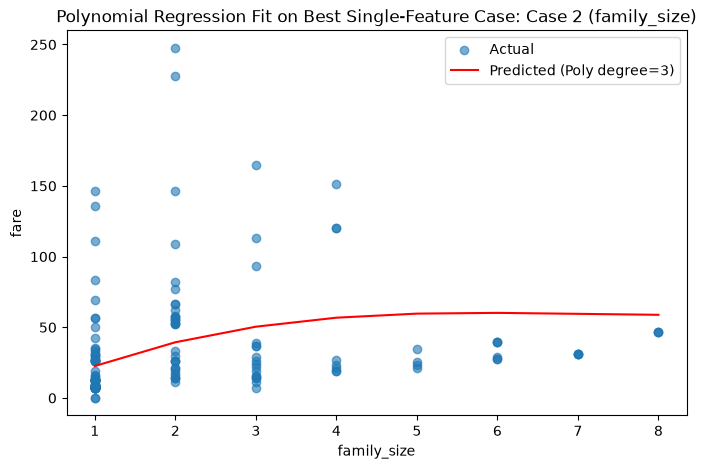

Polynomial case used: Case 2 (family_size)


In [11]:
# Polynomial on the best single-feature case (always runs)
y_pred_poly = None
y_poly_test = None
poly_case_name = None

single_feature_cases = {
    'Case 1 (age)': (X1_train, X1_test, y1_train, y1_test),
    'Case 2 (family_size)': (X2_train, X2_test, y2_train, y2_test),
}

# Pick the better single-feature case by test RMSE from the linear results table
single_feature_results = linear_results[
    linear_results['Case'].isin(single_feature_cases.keys())
]
poly_case_name = single_feature_results.iloc[0]['Case']
X_poly_train, X_poly_test, y_poly_train, y_poly_test = single_feature_cases[
    poly_case_name
]

poly = PolynomialFeatures(degree=3)
X_train_poly = poly.fit_transform(X_poly_train)
X_test_poly = poly.transform(X_poly_test)

poly_model = LinearRegression().fit(X_train_poly, y_poly_train)
y_pred_poly = poly_model.predict(X_test_poly)

plt.figure(figsize=(8, 5))
x_vals = X_poly_test.iloc[:, 0]
order = np.argsort(x_vals.values)
plt.scatter(x_vals, y_poly_test, alpha=0.6, label='Actual')
plt.plot(
    x_vals.values[order],
    y_pred_poly[order],
    color='red',
    label='Predicted (Poly degree=3)',
)
plt.title(f'Polynomial Regression Fit on Best Single-Feature Case: {poly_case_name}')
plt.xlabel(X_poly_test.columns[0])
plt.ylabel('fare')
plt.legend()
plt.show()

print('Polynomial case used:', poly_case_name)

In [12]:
def report_row(name, y_true, y_pred):
    return {
        'Model': name,
        'R2': r2_score(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE': mean_absolute_error(y_true, y_pred),
    }


model_rows = []
# Add linear baseline based on selected best case
linear_pred = LinearRegression().fit(Xb_train, yb_train).predict(Xb_test)
model_rows.append(report_row('Linear (best-case baseline)', yb_test, linear_pred))
model_rows.append(report_row('Ridge', yb_test, y_pred_ridge))
model_rows.append(report_row('Elastic Net', yb_test, y_pred_elastic))

if y_pred_poly is not None and y_poly_test is not None:
    model_rows.append(
        report_row(
            f'Polynomial (degree=3 on {poly_case_name})', y_poly_test, y_pred_poly
        )
    )

comparison = pd.DataFrame(model_rows).sort_values(by='RMSE')
display(comparison)

,Model,R2,RMSE,MAE
2,Elastic Net,0.428818,28.746805,17.388533
1,Ridge,0.399558,29.473929,20.048029
0,Linear (best-case baseline),0.398934,29.489236,20.082511
3,Polynomial (degree=3 on Case 2 (family_size)),0.088158,36.321370,24.065016


### Section 5 Reflection (Final)
- What patterns does the polynomial model capture?
  The cubic polynomial captured a curved relationship in the single-feature case and followed the broad trend of fare changing with family size.
- Where does it perform well or poorly?
  It fit the middle density range better than sparse extremes, where predictions were less accurate.
- Did polynomial outperform linear regression?
  No. Polynomial (degree 3 on Case 2) had test $R^2$ 0.088, RMSE 36.321, and MAE 24.065, which is much worse than Elastic Net (test $R^2$ 0.429, RMSE 28.747, MAE 17.389).
- Which model appears most reliable and why?
  Elastic Net appears most reliable for this Titanic setup because it had the best combined test metrics (highest $R^2$, lowest RMSE, and lowest MAE) among the compared models.

## Section 6: Final Thoughts and Insights

### 6.1 Summarize Findings
- The most useful features were class- and demographic-related inputs, especially when combined (`age`, `family_size`, `pclass`, and `sex_code`).
- In the Titanic comparison, the strongest model was Elastic Net, with test $R^2$ 0.429, RMSE 28.747, and MAE 17.389.
- Model complexity only helped when it improved test performance; the polynomial single-feature fit did not outperform the stronger multi-feature models.

### 6.2 Discuss Challenges
- Fare was moderately difficult to predict because the target is skewed and influenced by multiple interacting factors (class, demographics, and travel context).
- Outliers and uneven density likely affected error behavior, especially in sparse regions.

### 6.3 Optional Next Steps
- Tune Elastic Net and Ridge hyperparameters with cross-validation.
- Test log-transforming `fare` to reduce skew.
- Add additional engineered interactions and compare stability across repeated splits.


## Bonus (Optional): Additional Regression Dataset - Diamonds

This bonus section applies the same structured process to a second dataset.

### Goal
Predict `price` (continuous numeric target) from diamond attributes.

### Plan
1. Load and inspect the diamonds dataset.
2. Prepare numeric and encoded feature sets.
3. Train baseline and regularized models.
4. Compare model metrics.
5. Add a short interpretation of results.

In [13]:
# Bonus 1: Load and inspect diamonds dataset

diamonds = sns.load_dataset('diamonds').copy()

print('Shape:', diamonds.shape)
display(diamonds.head())
display(diamonds.describe(include='all'))

Shape: (53940, 10)


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


,carat,cut,color,clarity,depth,table,price,x,y,z
count,53940.000000,53940,53940,53940,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
unique,NaN,5,7,8,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Ideal,G,SI1,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,21551,11292,13065,NaN,NaN,NaN,NaN,NaN,NaN
mean,0.797940,NaN,NaN,NaN,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,NaN,NaN,NaN,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,NaN,NaN,NaN,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,NaN,NaN,NaN,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,NaN,NaN,NaN,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,NaN,NaN,NaN,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000


In [14]:
# Bonus 2: Prepare feature sets

# Keep runtime reasonable while preserving variety in the data.
diamonds_sample = diamonds.sample(n=12000, random_state=123).copy()

# One-hot encode categorical columns.
diamonds_encoded = pd.get_dummies(
    diamonds_sample,
    columns=['cut', 'color', 'clarity'],
    drop_first=True,
)

# Target
y_bonus = diamonds_encoded['price']

# Feature set A: numeric core only
X_bonus_core = diamonds_encoded[['carat', 'depth', 'table', 'x', 'y', 'z']]

# Feature set B: core + encoded categoricals
bonus_feature_cols = [c for c in diamonds_encoded.columns if c != 'price']
X_bonus_full = diamonds_encoded[bonus_feature_cols]

# Train/test split
X_core_train, X_core_test, y_bonus_train, y_bonus_test = train_test_split(
    X_bonus_core, y_bonus, test_size=0.2, random_state=123
)
X_full_train, X_full_test, _, _ = train_test_split(
    X_bonus_full, y_bonus, test_size=0.2, random_state=123
)

print('Core feature shape:', X_bonus_core.shape)
print('Full feature shape:', X_bonus_full.shape)

Core feature shape: (12000, 6)
Full feature shape: (12000, 23)


In [15]:
# Bonus 3: Train models and compare (Linear, Ridge, Elastic Net, Polynomial)


def bonus_metrics_row(model_name, y_true, y_pred):
    return {
        'Model': model_name,
        'R2': r2_score(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE': mean_absolute_error(y_true, y_pred),
    }


# Linear on full feature set
bonus_linear = LinearRegression().fit(X_full_train, y_bonus_train)
y_pred_bonus_linear = bonus_linear.predict(X_full_test)

# Ridge on full feature set
bonus_ridge = Ridge(alpha=2.0).fit(X_full_train, y_bonus_train)
y_pred_bonus_ridge = bonus_ridge.predict(X_full_test)

# Elastic Net on full feature set
bonus_elastic = ElasticNet(
    alpha=0.05, l1_ratio=0.4, random_state=123, max_iter=20000
).fit(X_full_train, y_bonus_train)
y_pred_bonus_elastic = bonus_elastic.predict(X_full_test)

# Polynomial on single feature (carat)
X_poly_bonus_train = X_core_train[['carat']]
X_poly_bonus_test = X_core_test[['carat']]

poly_bonus = PolynomialFeatures(degree=3)
X_poly_bonus_train_t = poly_bonus.fit_transform(X_poly_bonus_train)
X_poly_bonus_test_t = poly_bonus.transform(X_poly_bonus_test)

bonus_poly_model = LinearRegression().fit(X_poly_bonus_train_t, y_bonus_train)
y_pred_bonus_poly = bonus_poly_model.predict(X_poly_bonus_test_t)

bonus_results = pd.DataFrame(
    [
        bonus_metrics_row('Linear (full features)', y_bonus_test, y_pred_bonus_linear),
        bonus_metrics_row('Ridge (full features)', y_bonus_test, y_pred_bonus_ridge),
        bonus_metrics_row(
            'Elastic Net (full features)', y_bonus_test, y_pred_bonus_elastic
        ),
        bonus_metrics_row(
            'Polynomial degree=3 (carat only)', y_bonus_test, y_pred_bonus_poly
        ),
    ]
).sort_values(by='RMSE')

display(bonus_results)

,Model,R2,RMSE,MAE
1,Ridge (full features),0.920015,1137.579538,751.995853
0,Linear (full features),0.919898,1138.409238,750.836634
2,Elastic Net (full features),0.868923,1456.265208,1080.860486
3,Polynomial degree=3 (carat only),0.864908,1478.402786,866.112649


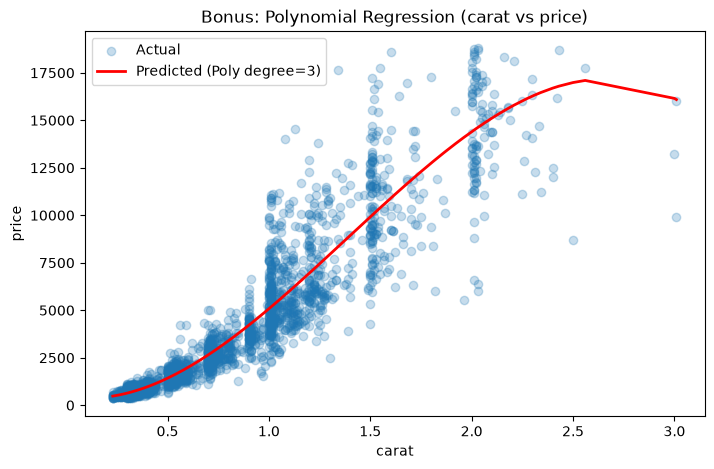

In [16]:
# Bonus 4: Visualize polynomial fit for carat -> price

plt.figure(figsize=(8, 5))
plt.scatter(X_poly_bonus_test['carat'], y_bonus_test, alpha=0.25, label='Actual')

order_bonus = np.argsort(X_poly_bonus_test['carat'].values)
plt.plot(
    X_poly_bonus_test['carat'].values[order_bonus],
    y_pred_bonus_poly[order_bonus],
    color='red',
    linewidth=2,
    label='Predicted (Poly degree=3)',
)

plt.title('Bonus: Polynomial Regression (carat vs price)')
plt.xlabel('carat')
plt.ylabel('price')
plt.legend()
plt.show()

### Bonus Reflection
- The best test **RMSE** was from **Ridge (full features)** at about **1137.58**, and the best test **MAE** was from **Linear (full features)** at about **750.84** (Ridge was very close at about **752.00**). This suggests the full feature set is the biggest driver of performance.
- Regularization gave a small generalization benefit: Ridge slightly improved RMSE over plain linear regression, while Elastic Net underperformed for this parameter setting.
- The polynomial model using only `carat` captured the main curved trend between carat and price, but it missed structure created by quality-related variables (`cut`, `color`, `clarity`) and had noticeably higher error.
- One concrete next improvement is to tune Elastic Net and Ridge hyperparameters with cross-validation, then test a log-transform of `price` to reduce skew and improve error stability.

### Bonus Summary Sentence
On the diamonds dataset, the strongest model by test RMSE was **Ridge (full features)**, suggesting that combining geometric and quality-related predictors with light regularization provides the most reliable signal for predicting `price`.